In [1]:
import os
import sys
sys.stdout = open(os.devnull, 'w')

import pandas as pd 
import numpy as np
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import matplotlib.pyplot as plt

import seaborn as sns
#import nltk; nltk.download('all')
from nltk.corpus import stopwords

from nltk.stem import WordNetLemmatizer
from nltk.tag import pos_tag
from nltk.tokenize import word_tokenize
import re
from PIL import Image, ImageOps
sys.stdout = sys.__stdout__

[{"variableName": "df", "type": "pandas", "supportedEngines": ["pandas"], "isLocalVariable": false, "rawType": "pandas.core.frame.DataFrame"}]
[{"variableName": "df", "type": "pandas", "supportedEngines": ["pandas"], "isLocalVariable": false, "rawType": "pandas.core.frame.DataFrame"}]
[{"variableName": "df", "type": "pandas", "supportedEngines": ["pandas"], "isLocalVariable": false, "rawType": "pandas.core.frame.DataFrame"}]
[{"variableName": "df", "type": "pandas", "supportedEngines": ["pandas"], "isLocalVariable": false, "rawType": "pandas.core.frame.DataFrame"}]
[{"variableName": "df", "type": "pandas", "supportedEngines": ["pandas"], "isLocalVariable": false, "rawType": "pandas.core.frame.DataFrame"}]
[{"variableName": "df", "type": "pandas", "supportedEngines": ["pandas"], "isLocalVariable": false, "rawType": "pandas.core.frame.DataFrame"}]
{"type": "pandas", "supportedEngines": ["pandas"], "rawType": "pandas.core.frame.DataFrame"}
[{"variableName": "df", "type": "pandas", "suppor

In [2]:
df = pd.read_csv("/Users/shifamaqsood/Desktop/RedditAnalysis2/reddit_fetching_script.csv")

In [3]:
df.head(5)

,Post Title,Post Content,Comment Body,Upvotes
0,The Barbie Movie's Unexpected Message for Men:...,"I know the movie has been out for ages, but he...",I loved it. Especially as a dude who grew up t...,6772
1,The Barbie Movie's Unexpected Message for Men:...,"I know the movie has been out for ages, but he...",One scene that stuck to me was when ~~Gosling~...,3057
2,The Barbie Movie's Unexpected Message for Men:...,"I know the movie has been out for ages, but he...",Aren't the gender roles switched in Barbieland...,1660
3,The Barbie Movie's Unexpected Message for Men:...,"I know the movie has been out for ages, but he...",I saw a post on Reddit recently that said some...,967
4,The Barbie Movie's Unexpected Message for Men:...,"I know the movie has been out for ages, but he...",I think I struggle with self worth.,164


In [3]:

df['LowercaseComments'] = df['Comment Body'].str.lower()

In [4]:

deleted_string = (['[deleted]  ^^^^^^^^^^^^^^^^0.4656'])
df = df[~df['LowercaseComments'].isin(deleted_string)]

In [5]:
#import the custom stopwords
stopwords =set()
with open("en_stopwords.txt", "r") as file:
    for word in file:
        stopwords.add(word.rstrip("\n"))

In [6]:


# Initialize stopwords and lemmatizer
lemmatizer = WordNetLemmatizer()

def text_preprocessing(text):
    try:
        # Ensure input is a string
        if not isinstance(text, str):
            return [], ""
        
        # Initialize regex patterns
        url_pattern = r"(https?://[^\s]+|www\.[^\s]+|[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}(?:/[^\s]*)?)"
        user_pattern = r"u/[^\s]+"
        entity_pattern = r"&.*;"
        negative_contraction = r"n't\W"
        non_alphabet = "[^a-z]"  # Matches anything NOT a lowercase letter
        
        # Preprocess the text
        cleaned_text = text.lower()
        cleaned_text = re.sub(negative_contraction, "not", cleaned_text)
        cleaned_text = re.sub(url_pattern, " ", cleaned_text)
        cleaned_text = re.sub(user_pattern, " ", cleaned_text)
        cleaned_text = re.sub(entity_pattern, " ", cleaned_text)
        cleaned_text = re.sub(non_alphabet, " ", cleaned_text)
        
        # Tokenize and POS tagging
        tokens = word_tokenize(cleaned_text, language='english', preserve_line=True)
        word_tag_tuples = pos_tag(tokens, tagset="universal")
        
        # Map POS tags to lemmatizer format
        tag_dict = {"NOUN": "n", "VERB": "v", "ADJ": "a", "ADV": "r"}
        final_tokens = []
        
        # Lemmatize tokens
        for word, tag in word_tag_tuples:
            if len(word) > 1 and word not in stopwords:
                if tag in tag_dict:
                    final_tokens.append(lemmatizer.lemmatize(word, tag_dict[tag]))
                else:
                    final_tokens.append(lemmatizer.lemmatize(word))
        
        # Return tokens and cleaned text
        return final_tokens, " ".join(final_tokens)
    except Exception as e:
        print(f"Error processing text: {e}")
        return [], ""


In [7]:
df["cleaned_tokens"], df["cleaned_text"] = zip(*df["LowercaseComments"].apply(text_preprocessing))

In [8]:
df.to_csv("barbie_cleaned.csv", index=False)

In [9]:
print(df["LowercaseComments"].isnull().sum())  # Count missing values
print(df["LowercaseComments"].dtype)

In [10]:
# word frequency 
import collections

In [11]:
word_count_list = df['cleaned_tokens']

flattened_list = []

for sublist in word_count_list:
    for item in sublist:
        flattened_list.append(item)


In [12]:
count_words = collections.Counter(flattened_list)
(count_words)

Counter({'movie': 526,
         'barbie': 434,
         'like': 273,
         'not': 215,
         'get': 197,
         'ken': 178,
         'go': 176,
         'see': 168,
         'one': 164,
         'think': 158,
         'make': 153,
         'all': 149,
         'what': 136,
         'film': 134,
         'really': 122,
         'how': 116,
         'out': 114,
         'woman': 112,
         'look': 110,
         'people': 102,
         'more': 98,
         'no': 94,
         'because': 93,
         'who': 92,
         'up': 90,
         'say': 89,
         'good': 87,
         'year': 87,
         'than': 82,
         'best': 77,
         'thing': 76,
         'time': 75,
         'oppenheimer': 74,
         'well': 73,
         'come': 71,
         'want': 69,
         'watch': 67,
         'know': 65,
         'gosling': 64,
         'great': 62,
         'love': 61,
         'robbie': 59,
         'play': 58,
         'only': 57,
         'lot': 57,
         'margot': 56,
  

In [13]:
from nltk import bigrams
from nltk import FreqDist


bigram_list = list(bigrams(flattened_list))
bigram_count = collections.Counter(bigram_list)

In [14]:
bigram_count

Counter({('barbie', 'movie'): 58,
         ('margot', 'robbie'): 45,
         ('ryan', 'gosling'): 41,
         ('gon', 'na'): 34,
         ('greta', 'gerwig'): 33,
         ('avg', 'metascore'): 24,
         ('feel', 'like'): 23,
         ('amy', 'schumer'): 22,
         ('look', 'like'): 21,
         ('more', 'than'): 20,
         ('come', 'out'): 19,
         ('real', 'world'): 19,
         ('th', 'avg'): 18,
         ('like', 'barbie'): 17,
         ('see', 'movie'): 17,
         ('no', 'one'): 15,
         ('people', 'who'): 15,
         ('michael', 'cera'): 15,
         ('see', 'barbie'): 14,
         ('movie', 'go'): 13,
         ('movie', 'look'): 13,
         ('best', 'picture'): 13,
         ('zone', 'interest'): 13,
         ('fun', 'movie'): 12,
         ('want', 'see'): 12,
         ('seem', 'like'): 12,
         ('go', 'see'): 12,
         ('watch', 'barbie'): 12,
         ('rather', 'than'): 12,
         ('felt', 'like'): 11,
         ('gerwig', 'barbie'): 11,
         (

In [15]:
#make a word cloud by joining together 

text = " ".join(flattened_list)  # Converts token list back into a full sentence


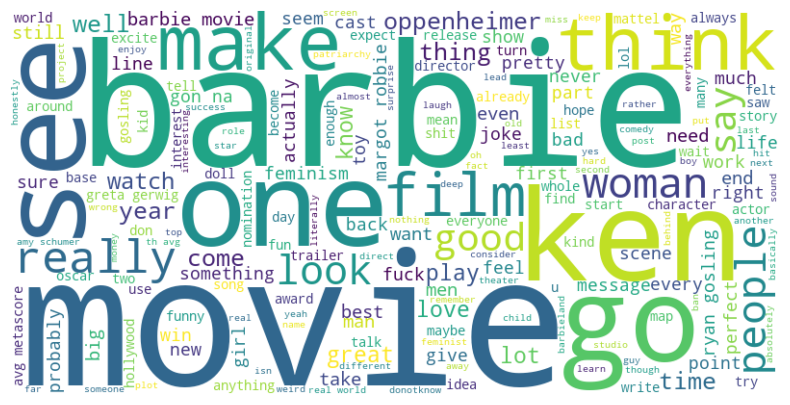

In [16]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()


In [17]:
from pathlib import Path
current_directory = Path.cwd()
print(current_directory)




In [18]:
# now im gonna make a custom Barbie word cloud 
barbie_mask = np.array(Image.open('./barbie_final_mask.png'))






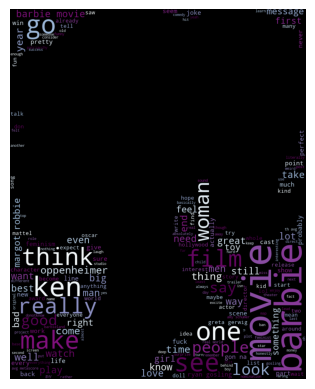

In [19]:
wc = WordCloud(background_color = 'black', mask = barbie_mask, contour_width = 2,
     contour_color = 'black', colormap = 'BuPu_r', width = 800, height = 500).generate(text)
plt.axis("off")
plt.imshow(wc)

In [20]:
from wordcloud import WordCloud
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt


def word_cloud(text):

# Load the fixed Barbie mask
    mask = np.array(Image.open("barbie_final_mask.png").convert("L"))

# WordCloud expects white = 255, black = 0 — we're good already
# Sample Barbie-core text
    mask = np.where(mask == 255, 0, 255).astype(np.uint8)

# Generate the word cloud
    wc = WordCloud(
        background_color="white",
        mask=mask,
        contour_color="black",
        contour_width=2,
        colormap="spring",  # Try 'pink', 'Purples', 'plasma', etc.
    ).generate(text)

# Display it
    fig =plt.figure(figsize=(8, 8))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.tight_layout()
    return fig



In [21]:
def word_cloud(text):
    mask = np.array(Image.open("barbie_final_mask.png").convert("L"))
    mask = np.where(mask == 255, 0, 255).astype(np.uint8)

    wc = WordCloud(
        background_color="white",
        mask=mask,
        contour_color="black",
        contour_width=2,
        colormap="spring",
    ).generate(text)

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    plt.tight_layout()

    return fig

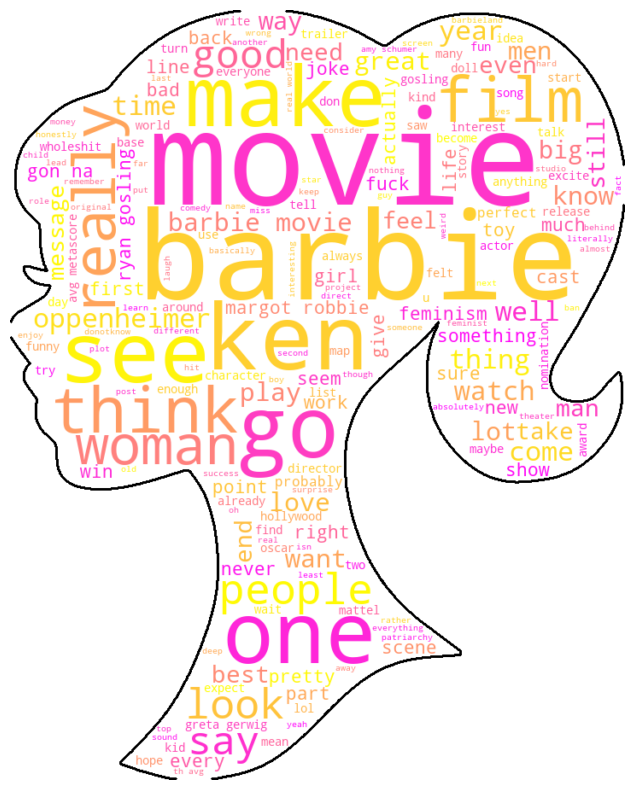

In [22]:
word_cloud(text);

In [23]:
# now find out scoring from both Vader and texy blob 

sid = SentimentIntensityAnalyzer()
df['scores'] = df['Comment Body'].apply(lambda x: sid.polarity_scores(x))
df.head()

,Post Title,Post Content,Comment Body,Upvotes,LowercaseComments,cleaned_tokens,cleaned_text,scores
0,The Barbie Movie's Unexpected Message for Men:...,"I know the movie has been out for ages, but he...",I loved it. Especially as a dude who grew up t...,6772,i loved it. especially as a dude who grew up t...,"[love, especially, dude, who, grow, up, think,...",love especially dude who grow up think loser n...,"{'neg': 0.086, 'neu': 0.655, 'pos': 0.259, 'co..."
1,The Barbie Movie's Unexpected Message for Men:...,"I know the movie has been out for ages, but he...",One scene that stuck to me was when ~~Gosling~...,3057,one scene that stuck to me was when ~~gosling~...,"[one, scene, stick, gosling, beach, ken, throw...",one scene stick gosling beach ken throw white ...,"{'neg': 0.085, 'neu': 0.761, 'pos': 0.154, 'co..."
2,The Barbie Movie's Unexpected Message for Men:...,"I know the movie has been out for ages, but he...",Aren't the gender roles switched in Barbieland...,1660,aren't the gender roles switched in barbieland...,"[arenotthe, gender, role, switch, barbieland, ...",arenotthe gender role switch barbieland think ...,"{'neg': 0.051, 'neu': 0.911, 'pos': 0.039, 'co..."
3,The Barbie Movie's Unexpected Message for Men:...,"I know the movie has been out for ages, but he...",I saw a post on Reddit recently that said some...,967,i saw a post on reddit recently that said some...,"[saw, post, reddit, recently, say, something, ...",saw post reddit recently say something like lo...,"{'neg': 0.07, 'neu': 0.729, 'pos': 0.201, 'com..."
4,The Barbie Movie's Unexpected Message for Men:...,"I know the movie has been out for ages, but he...",I think I struggle with self worth.,164,i think i struggle with self worth.,"[think, struggle, self, worth]",think struggle self worth,"{'neg': 0.25, 'neu': 0.543, 'pos': 0.207, 'com..."


In [24]:
# make a compund column and label sentiments as positive, negative or neutral
# use research instead of chatpt to classify comopund 

df['compound'] = df['scores'].apply(lambda x: x['compound'])

#label 

df['Sentiment_Type'] = ''
df.loc[df['compound'] >= 0.05, 'Sentiment_Type'] = 'Positive'
df.loc[(df['compound'] >= -0.05) & (df['compound'] <= 0.05), 'Sentiment_Type'] = 'Neutral'
df.loc[df['compound'] <= -0.05, 'Sentiment_Type'] = 'Negative'
#note vader does not understand context as perfectly since it is lexicon based


In [25]:
# now we will also try text blob maybe just for comparison 

from textblob import TextBlob


def get_polarity(text):
    return TextBlob(text).sentiment.polarity
df['TextBlob_Polarity'] = df['cleaned_text'].apply(get_polarity)

In [26]:
df['TextBlob_Sentiment_Type']=''
df.loc[df.TextBlob_Polarity>0,'TextBlob_Sentiment_Type']='POSITIVE'
df.loc[df.TextBlob_Polarity==0,'TextBlob_Sentiment_Type']='NEUTRAL'
df.loc[df.TextBlob_Polarity<0,'TextBlob_Sentiment_Type']='NEGATIVE'

<Axes: xlabel='Sentiment_Type'>

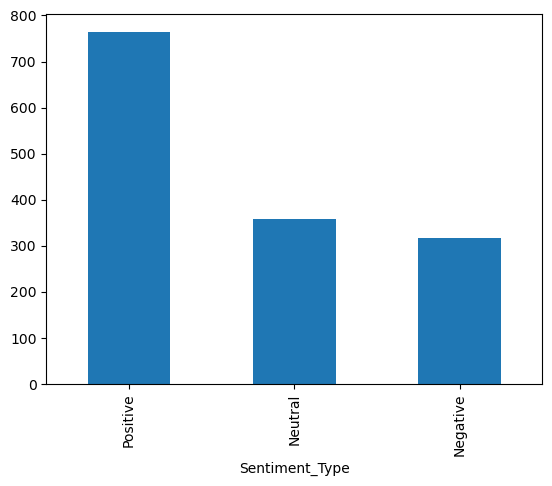

In [27]:
# count the sentiment types for both

df.Sentiment_Type.value_counts().plot(kind='bar')

<Axes: xlabel='TextBlob_Sentiment_Type'>

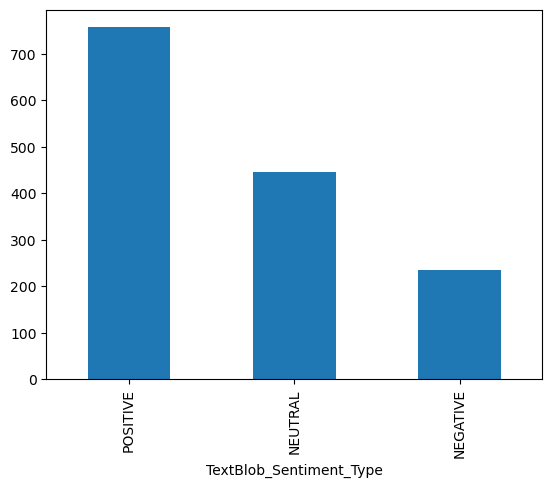

In [28]:
# count textblod sentiment types

df.TextBlob_Sentiment_Type.value_counts().plot(kind='bar')

In [29]:
# next step? # make pie chart of overall sentiment

def sentiment_pie_chart(df):
   sentiment_counts =  df['Sentiment_Type'].value_counts()

   sentiment_counts.plot(kind ='pie', autopct='%1.1f%%', colors=['skyblue', 'lightgreen', 'lightcoral'])
   plt.title('Distribution of Sentiment') 
   plt.ylabel('')
         

   return 
   


In [30]:

def sentiment_pie_chart(df):
    sentiment_counts = df['Sentiment_Type'].value_counts()

    fig, ax = plt.subplots()
    sentiment_counts.plot(
        kind='pie',
        autopct='%1.1f%%',
        colors=['skyblue', 'lightgreen', 'lightcoral'],
        ax=ax,
        legend=False,
        ylabel=''
    )
    
    ax.set_title('Distribution of Sentiment')
    ax.axis('equal')  # make it a circle

    return fig

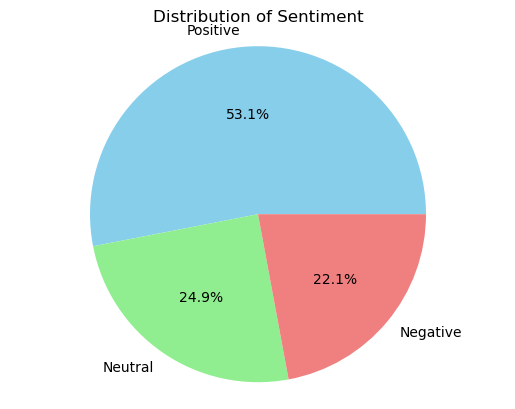

In [31]:
_=sentiment_pie_chart(df)

In [32]:
# i want to show top 10 positive comments and make sure that i give users options to change it ti negative or neutral 

positive_comments = df[df["compound"]>0.7].sort_values(by ="compound", ascending= False)
# show the comments, score and upvotes

top_10_comments = positive_comments[['Comment Body', 'Upvotes', 'compound']].sort_values(by = "compound", ascending= False).head(10)

In [33]:
#so the top 10 positive comments are not positive?
# now i have to extract actual positive compounds. can nor just use the compound score.

df['Upvotes'].max()
# maybe i could combine score with upvotes? and not just the compound score
# a custom function to make sure comments are positive and got upvotes 



30334

In [34]:
# def isactually_positive(row): 

#     score = row["scores"]
#     return (
#         row["compound"] > 0.7 and 
#         score["pos"] > 0.3 and 
#         score ["pos"] > score["neg"] * 2 and 
#         row["Upvotes"] >= 10)

# commented it out for non-repitition 

In [35]:
#top_positive = df[df.apply(isactually_positive, axis=1)]


In [36]:
#top_positive = top_positive.sort_values(by="Upvotes", ascending=False).head(10)


479.8000000000002

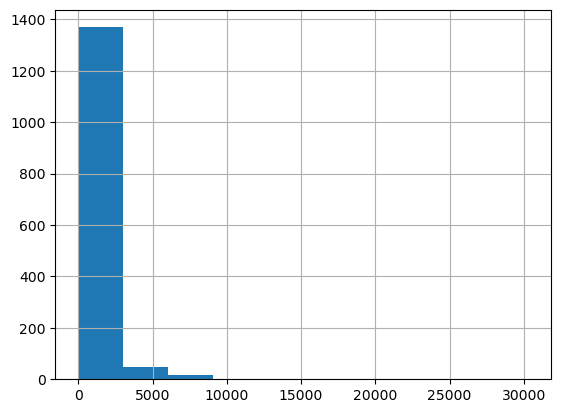

In [37]:
#so most upvoted commments are not posiitve so maybe make a histogram of where most upvotes fall?
histogram_upvotes = df['Upvotes'].hist(bins=10)

threshold = df['Upvotes'].quantile(0.8)
threshold




In [38]:
def isactually_positive(row): 

    score = row["scores"]
    return (
        row["compound"] > 0.7 and 
        #score["pos"] > 0.3 and 
        #score ["pos"] > score["neg"] * 2 and 
        row["Upvotes"] >= threshold)

In [39]:
top_positive = df[df.apply(isactually_positive, axis=1)]

In [40]:
top_positive = top_positive.sort_values(by="Upvotes", ascending=False).head(10)

#captures good postive comments


In [43]:
print(type(top_positive))
print("hello")


In [47]:
type(top_positive)

pandas.core.frame.DataFrame

In [48]:
df

,Post Title,Post Content,Comment Body,Upvotes,LowercaseComments,cleaned_tokens,cleaned_text,scores,compound,Sentiment_Type,TextBlob_Polarity,TextBlob_Sentiment_Type
0,The Barbie Movie's Unexpected Message for Men:...,"I know the movie has been out for ages, but he...",I loved it. Especially as a dude who grew up t...,6772,i loved it. especially as a dude who grew up t...,"[love, especially, dude, who, grow, up, think,...",love especially dude who grow up think loser n...,"{'neg': 0.086, 'neu': 0.655, 'pos': 0.259, 'co...",0.7845,Positive,0.400000,POSITIVE
1,The Barbie Movie's Unexpected Message for Men:...,"I know the movie has been out for ages, but he...",One scene that stuck to me was when ~~Gosling~...,3057,one scene that stuck to me was when ~~gosling~...,"[one, scene, stick, gosling, beach, ken, throw...",one scene stick gosling beach ken throw white ...,"{'neg': 0.085, 'neu': 0.761, 'pos': 0.154, 'co...",0.9076,Positive,-0.030357,NEGATIVE
2,The Barbie Movie's Unexpected Message for Men:...,"I know the movie has been out for ages, but he...",Aren't the gender roles switched in Barbieland...,1660,aren't the gender roles switched in barbieland...,"[arenotthe, gender, role, switch, barbieland, ...",arenotthe gender role switch barbieland think ...,"{'neg': 0.051, 'neu': 0.911, 'pos': 0.039, 'co...",0.1658,Positive,0.179167,POSITIVE
3,The Barbie Movie's Unexpected Message for Men:...,"I know the movie has been out for ages, but he...",I saw a post on Reddit recently that said some...,967,i saw a post on reddit recently that said some...,"[saw, post, reddit, recently, say, something, ...",saw post reddit recently say something like lo...,"{'neg': 0.07, 'neu': 0.729, 'pos': 0.201, 'com...",0.9753,Positive,0.173077,POSITIVE
4,The Barbie Movie's Unexpected Message for Men:...,"I know the movie has been out for ages, but he...",I think I struggle with self worth.,164,i think i struggle with self worth.,"[think, struggle, self, worth]",think struggle self worth,"{'neg': 0.25, 'neu': 0.543, 'pos': 0.207, 'com...",-0.1027,Negative,0.300000,POSITIVE
...,...,...,...,...,...,...,...,...,...,...,...,...
1436,Has a film ever had more promotion than Greta ...,Look I am a hardcore Barbie collector and hard...,In 1977/1978 it was Star Wars. I loved it!,2,in 1977/1978 it was star wars. i loved it!,"[star, war, love]",star war love,"{'neg': 0.243, 'neu': 0.473, 'pos': 0.283, 'co...",0.1511,Positive,0.500000,POSITIVE
1437,Has a film ever had more promotion than Greta ...,Look I am a hardcore Barbie collector and hard...,Last Action Hero has some crazier advertising ...,2,last action hero has some crazier advertising ...,"[last, action, hero, crazier, advertising, story]",last action hero crazier advertising story,"{'neg': 0.103, 'neu': 0.561, 'pos': 0.336, 'co...",0.5423,Positive,0.050000,POSITIVE
1438,Has a film ever had more promotion than Greta ...,Look I am a hardcore Barbie collector and hard...,It must be your search history or something si...,2,it must be your search history or something si...,"[must, search, history, something, similar, be...",must search history something similar because ...,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,Neutral,0.000000,NEUTRAL
1439,Has a film ever had more promotion than Greta ...,Look I am a hardcore Barbie collector and hard...,Were you alive when tim burtons batman came out?,2,were you alive when tim burtons batman came out?,"[alive, tim, burton, batman, come, out]",alive tim burton batman come out,"{'neg': 0.0, 'neu': 0.755, 'pos': 0.245, 'comp...",0.3818,Positive,0.100000,POSITIVE


In [49]:
# now i need to do top negative comments 

# upvotes was considered for top 10 positive comments but how should i deal with it

## neg_threshold = df['Upvotes'].quantile()
## i am not going to do the quantile bc negative comments
## so only compound scores


def isactually_negative (row): 
    score = row["scores"]
    return (
             score["compound"] < -0.8 and
            score["neu"] >= 0.7 
        #score ["pos"] > score["neg"] * 2 and 
)



In [50]:

top_negative = df[df.apply(isactually_negative, axis=1 )]

top_negative = top_negative.sort_values(by="Upvotes", ascending=False).head(10)

## these top 10 negative comments arent really about the movie? but more like about countries banning it
## even after improving my fetching script to only focus on barbie post. idk i feel like my code is not capturing the essence of negative comments

## some negative comments are about other topics like countries who banned it

In [51]:
top_negative

,Post Title,Post Content,Comment Body,Upvotes,LowercaseComments,cleaned_tokens,cleaned_text,scores,compound,Sentiment_Type,TextBlob_Polarity,TextBlob_Sentiment_Type
146,Official Discussion - Barbie [SPOILERS],"#Poll\n\n**If you've seen the film, please rat...",The people suggesting to see Barbie before Opp...,3942,the people suggesting to see barbie before opp...,"[people, suggest, see, barbie, before, oppenhe...",people suggest see barbie before oppenheimer d...,"{'neg': 0.273, 'neu': 0.727, 'pos': 0.0, 'comp...",-0.8555,Negative,0.000000,NEUTRAL
216,Vietnam bans 'Barbie' movie over South China S...,NaN,"In Iran, to watch this movie we have to wait f...",840,"in iran, to watch this movie we have to wait f...","[iran, watch, movie, wait, month, movie, avail...",iran watch movie wait month movie available pvod,"{'neg': 0.279, 'neu': 0.721, 'pos': 0.0, 'comp...",-0.8519,Negative,0.400000,POSITIVE
1230,Of the highest grossing domestic movies of the...,I was looking at the list of highest grossing ...,Transformers Revenge of the Fallen is a garbag...,411,transformers revenge of the fallen is a garbag...,"[transformer, revenge, fallen, garbage, movie,...",transformer revenge fallen garbage movie few e...,"{'neg': 0.238, 'neu': 0.701, 'pos': 0.06, 'com...",-0.9407,Negative,0.112500,POSITIVE
478,The rudimentary feminism of Barbie,"As award season discussion ramps up, I've seen...",> unprecedented feminist Trojan horse\n\nCapit...,48,> unprecedented feminist trojan horse\n\ncapit...,"[unprecedented, feminist, trojan, horse, capit...",unprecedented feminist trojan horse capitalist...,"{'neg': 0.169, 'neu': 0.742, 'pos': 0.09, 'com...",-0.8481,Negative,0.083333,POSITIVE
1302,"MTRCB allows the screening of ""Barbie"" movie i...",NaN,the [offending map](https://twitter.com/rzhong...,47,the [offending map](https://twitter.com/rzhong...,"[offend, map, question, apparently, dash, lead...",offend map question apparently dash lead blob ...,"{'neg': 0.179, 'neu': 0.821, 'pos': 0.0, 'comp...",-0.8268,Negative,0.070000,POSITIVE
697,There's a lot to unpack in the Barbie movie bu...,"So first off, I love this movie.\n\nIt's laugh...",This isn't about Ken but my biggest disappoint...,32,this isn't about ken but my biggest disappoint...,"[isnotabout, ken, big, disappointment, film, v...",isnotabout ken big disappointment film vision ...,"{'neg': 0.168, 'neu': 0.731, 'pos': 0.101, 'co...",-0.8296,Negative,0.080000,POSITIVE
323,Hot Take: I Think Barbie is (Intentionally?) a...,"A bit late to the discussion, but only just sa...",Tbh Barbie is a movie that the more I think ab...,30,tbh barbie is a movie that the more i think ab...,"[tbh, barbie, movie, more, think, bad, get, to...",tbh barbie movie more think bad get ton messag...,"{'neg': 0.103, 'neu': 0.824, 'pos': 0.073, 'co...",-0.9184,Negative,0.109821,POSITIVE
1253,Amy Schumer reveals why she dropped out of Bar...,NaN,Amy Shumer is a rapist and doesn't deserve her...,26,amy shumer is a rapist and doesn't deserve her...,"[amy, shumer, rapist, doesnotdeserve, fame, tr...",amy shumer rapist doesnotdeserve fame transcri...,"{'neg': 0.278, 'neu': 0.722, 'pos': 0.0, 'comp...",-0.8077,Negative,0.000000,NEUTRAL
979,April 4-6 Box Office Recap: 'A Minecraft Movie...,https://preview.redd.it/3kitircrohte1.png?widt...,Wife and I went to see A Working Man Sunday af...,21,wife and i went to see a working man sunday af...,"[wife, go, see, work, man, sunday, afternoon, ...",wife go see work man sunday afternoon don horr...,"{'neg': 0.16, 'neu': 0.84, 'pos': 0.0, 'compou...",-0.8588,Negative,-0.458333,NEGATIVE
1364,I saw 54 movies in a theater this year. Here i...,Hello to anyone interested and about to read/s...,Poor Things was the best movie I saw in theate...,18,poor things was the best movie i saw in theate...,"[poor, thing, best, movie, saw, theater, year,...",poor thing best movie saw theater year also pu...,"{'neg': 0.174, 'neu': 0.765, 'pos': 0.061, 'co...",-0.8366,Negative,0.051791,POSITIVE


In [ ]:
#last visual

##maybe look at upvotes but like what?
 # first option is to see if long and critical comments ever get more upvotes?
## this could be am interesting dive that if u are looking at data from reddit, one of the things to be concsious of 
# maybe a scatterplot?

In [ ]:
#a simple scatterplot of word length and upvotes

df['Comment_Length'] = df['LowercaseComments'].str.len()

In [ ]:
plt.figure(figsize=(10,6))
plt.scatter(df["Comment_Length"], df["Upvotes"], alpha=0.5)
plt.xlabel("Comment Length (characters)")
plt.ylabel("Upvotes")
plt.title("Do Longer Comments Get More Upvotes?")
plt.grid(True)
plt.show()


In [ ]:

df.to_csv("barbie_cleaned2.csv", index=False)


